# Basic Kuramoto Model

This notebook explores the Kuramoto model with uniform all-to-all coupling.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

from kuramoto.config import (
    SimulationConfig, build_simulation,
    GridConfig, CouplingConfig, NeuronConfig,
    InitOmegaConfig, InitThetaConfig
)
from kuramoto.analysis import get_R
from kuramoto.plotting import animate_from_run, plot_2d

%matplotlib inline

In [3]:
# Higher level sim params
SEED = 42
T_END = 40.0
dt = 0.1
RNG = np.random.seed(SEED)

## 1. Coupling Strength Sweep

In [5]:
K_values = np.arange(0.2,2,0.2)
results_K = {}

# Grid spec
grid_cfg = GridConfig(shape=(32, 32))

# State and omega initialization
init_theta = InitThetaConfig(mode="uniform")
init_omega = InitOmegaConfig(mode="normal", mu=0, sigma=0.5)

for K in K_values:
    # Create sim config
    cfg = SimulationConfig(
        grid=grid_cfg,
        coupling=CouplingConfig(mode="uniform", base_strength=K),
        initial_theta=init_theta,
        initial_omega=init_omega,
        seed=SEED,
    )

    # Build sim
    sim = build_simulation(config=cfg, rng=RNG)

    # Run sim
    results = sim.run((0, T_END), dt, rng=RNG)
    t_list = results['ts'].tolist()
    state_list = [{'theta': th, 'theta_dot': dth, 'omega': results['omega']} for th, dth in zip(results['theta'], results['theta_dot'])]

    # Postprocess
    R_list, _ = get_R(results['theta'])

    results_K[K] = {
        "t_list": t_list, 
        "state_list": state_list,
        "R": R_list,
        "grid": sim.grid,
    }
    print(f"K = {K:.2f}: R_final = {R_list[-1]:.3f}")

K = 0.20: R_final = 0.015
K = 0.40: R_final = 0.026
K = 0.60: R_final = 0.084
K = 0.80: R_final = 0.397
K = 1.00: R_final = 0.728
K = 1.20: R_final = 0.861
K = 1.40: R_final = 0.914
K = 1.60: R_final = 0.938
K = 1.80: R_final = 0.956


### R(t) for Different Coupling Strengths

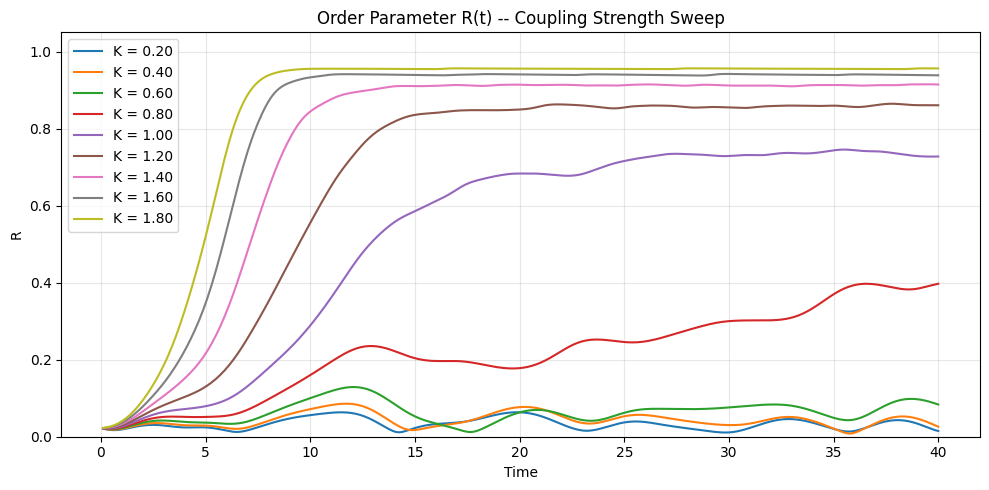

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
for K, res in results_K.items():
    ax.plot(res["t_list"], res["R"], linewidth=1.5, label=f"K = {K:.2f}")
ax.set_xlabel("Time")
ax.set_ylabel("R")
ax.set_ylim(0, 1.05)
ax.set_title("Order Parameter R(t) -- Coupling Strength Sweep")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Final R vs Coupling Strength

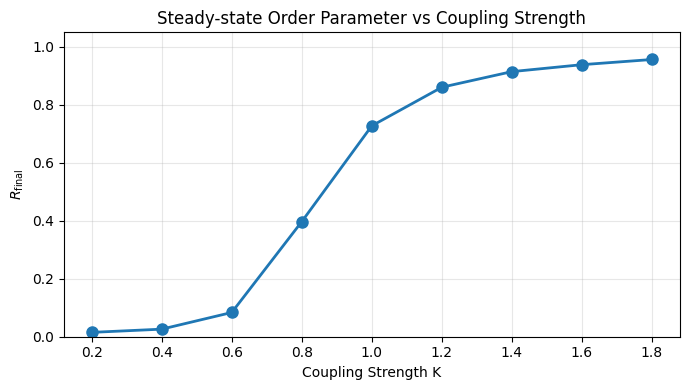

In [8]:
K_arr = sorted(results_K.keys())
R_final = [results_K[K]["R"][-1] for K in K_arr]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(K_arr, R_final, "o-", linewidth=2, markersize=8)
ax.set_xlabel("Coupling Strength K")
ax.set_ylabel(r"$R_{\mathrm{final}}$")
ax.set_ylim(0, 1.05)
ax.set_title("Steady-state Order Parameter vs Coupling Strength")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Phase Animation -- K = 0.3, 0.5, 0.9

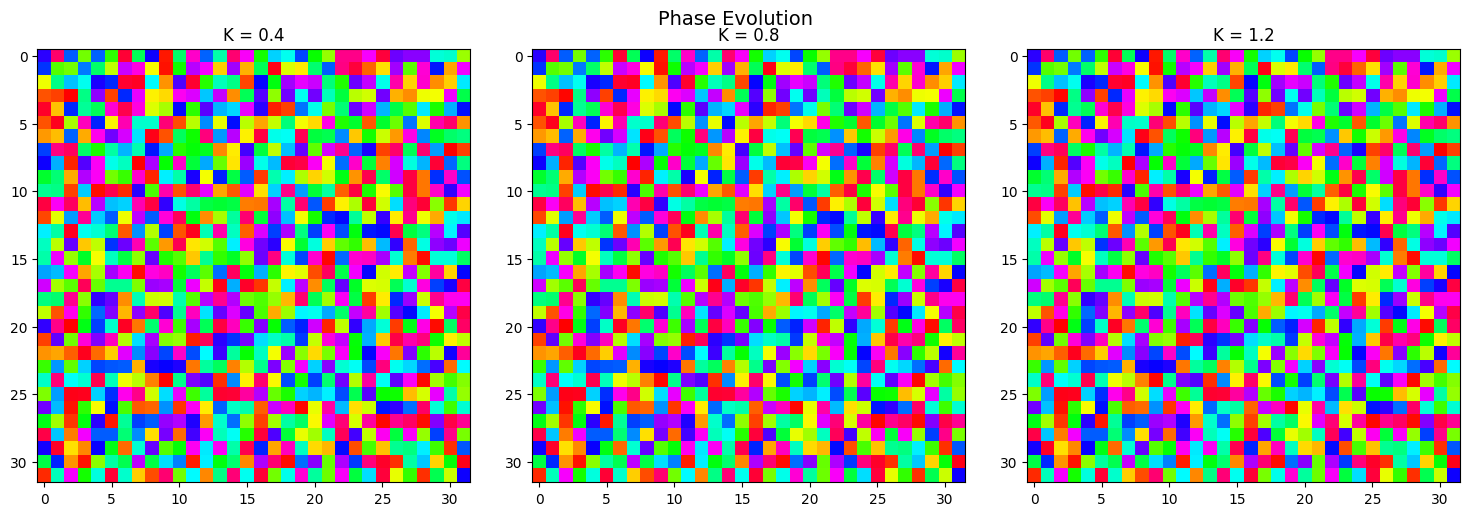

In [9]:
K_anim = [0.4, 0.8, 1.2]
ds = 4

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
ims = []
for ax, K in zip(axes, K_anim):
    res = results_K[K]
    grid = res["grid"]
    theta0_2d = grid.unflatten(res["state_list"][0]["theta"])
    im = ax.imshow(np.mod(theta0_2d, 2*np.pi), cmap="hsv", vmin=0, vmax=2*np.pi,
                   aspect="equal", interpolation="nearest")
    ax.set_title(f"K = {K}")
    ims.append(im)
plt.suptitle("Phase Evolution", fontsize=14)
plt.tight_layout()

indices = list(range(0, len(results_K[K_anim[0]]["state_list"]), ds))

def update(frame):
    idx = indices[frame]
    for im, K in zip(ims, K_anim):
        res = results_K[K]
        grid = res["grid"]
        theta_2d = grid.unflatten(res["state_list"][idx]["theta"])
        im.set_data(np.mod(theta_2d, 2*np.pi))
    fig.suptitle(f"Phase Evolution  t = {results_K[K_anim[0]]['t_list'][idx]:.1f}", fontsize=14)
    return ims

anim = FuncAnimation(fig, update, frames=len(indices), interval=80, blit=False)
plt.show()

## 1. Phase Initialization Comparison

In [10]:
init_modes = {
    "uniform": InitThetaConfig(mode="uniform"),
    "normal (sigma=0.5)": InitThetaConfig(mode="normal", mu=np.pi, sigma=0.5),
    "normal (sigma=1)": InitThetaConfig(mode="normal", mu=np.pi, sigma=1),
    "normal (sigma=2)": InitThetaConfig(mode="normal", mu=np.pi, sigma=2)
}

results_init = {}

# Base sim config
coupling_cfg = CouplingConfig(mode="uniform", base_strength=0.8) # Picking transitional K

for label, init_cfg in init_modes.items():
    # Configure sims
    cfg = SimulationConfig(
        grid=grid_cfg,
        coupling=coupling_cfg,
        initial_theta=init_cfg,
        seed=SEED,
    )

    sim = build_simulation(config=cfg, rng=RNG)

    results = sim.run((0, T_END), dt, rng=RNG)
    t_list = results['ts'].tolist()
    state_list = [{'theta': th, 'theta_dot': dth, 'omega': results['omega']} for th, dth in zip(results['theta'], results['theta_dot'])]
    
    t_R = t_list
    R_vals, _ = get_R(results['theta'])
    
    results_init[label] = {
        "t_list": t_list, "state_list": state_list,
        "t_R": t_R, "R": R_vals,
        "theta0": state_list[0]["theta"],
        "grid": sim.grid,
    }
    
    print(f"{label}: R_final = {R_vals[-1]:.3f}")

uniform: R_final = 0.396
normal (sigma=0.5): R_final = 0.456
normal (sigma=1): R_final = 0.462
normal (sigma=2): R_final = 0.465


### Initial Phase Distributions

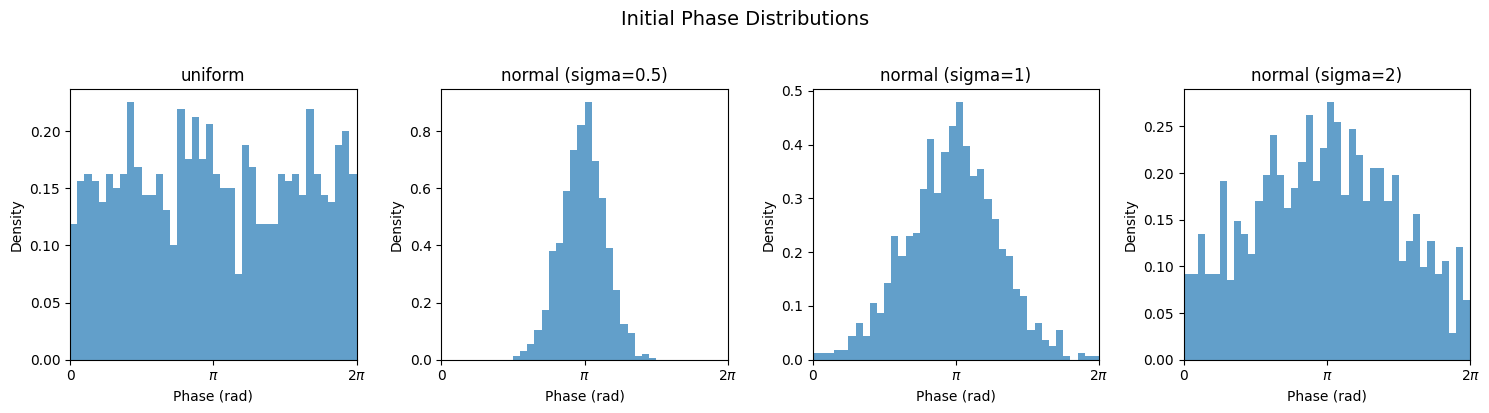

In [11]:
fig, axes = plt.subplots(1, len(init_modes), figsize=(15, 4))
for ax, (label, res) in zip(axes, results_init.items()):
    ax.hist(res["theta0"], bins=40, range=(0, 2 * np.pi), density=True, alpha=0.7)
    ax.set_xlabel("Phase (rad)")
    ax.set_ylabel("Density")
    ax.set_title(label)
    ax.set_xlim(0, 2 * np.pi)
    ax.set_xticks([0, np.pi, 2 * np.pi])
    ax.set_xticklabels(["0", r"$\pi$", r"$2\pi$"])
plt.suptitle("Initial Phase Distributions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Order Parameter R(t)

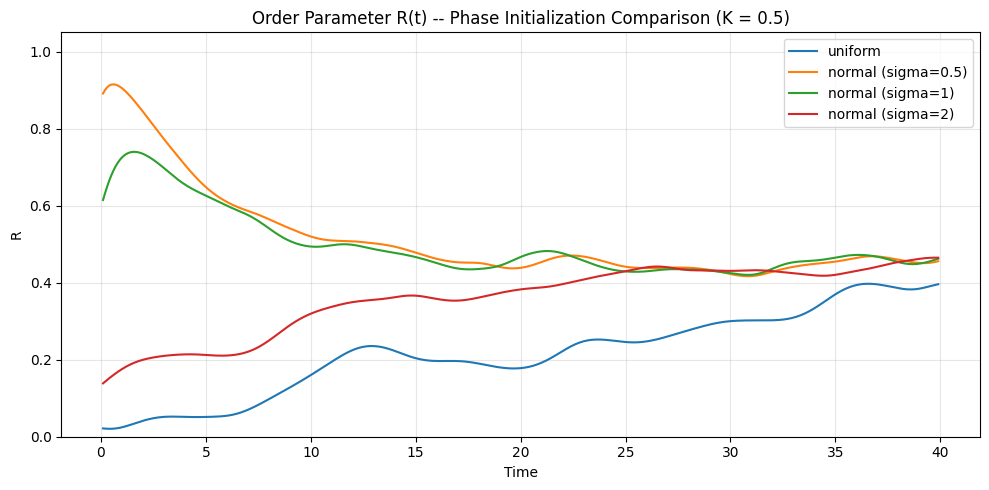

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
for label, res in results_init.items():
    ax.plot(res["t_R"], res["R"], linewidth=1.5, label=label)
ax.set_xlabel("Time")
ax.set_ylabel("R")
ax.set_ylim(0, 1.05)
ax.set_title("Order Parameter R(t) -- Phase Initialization Comparison (K = 0.8)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Phase Snapshots at start and end

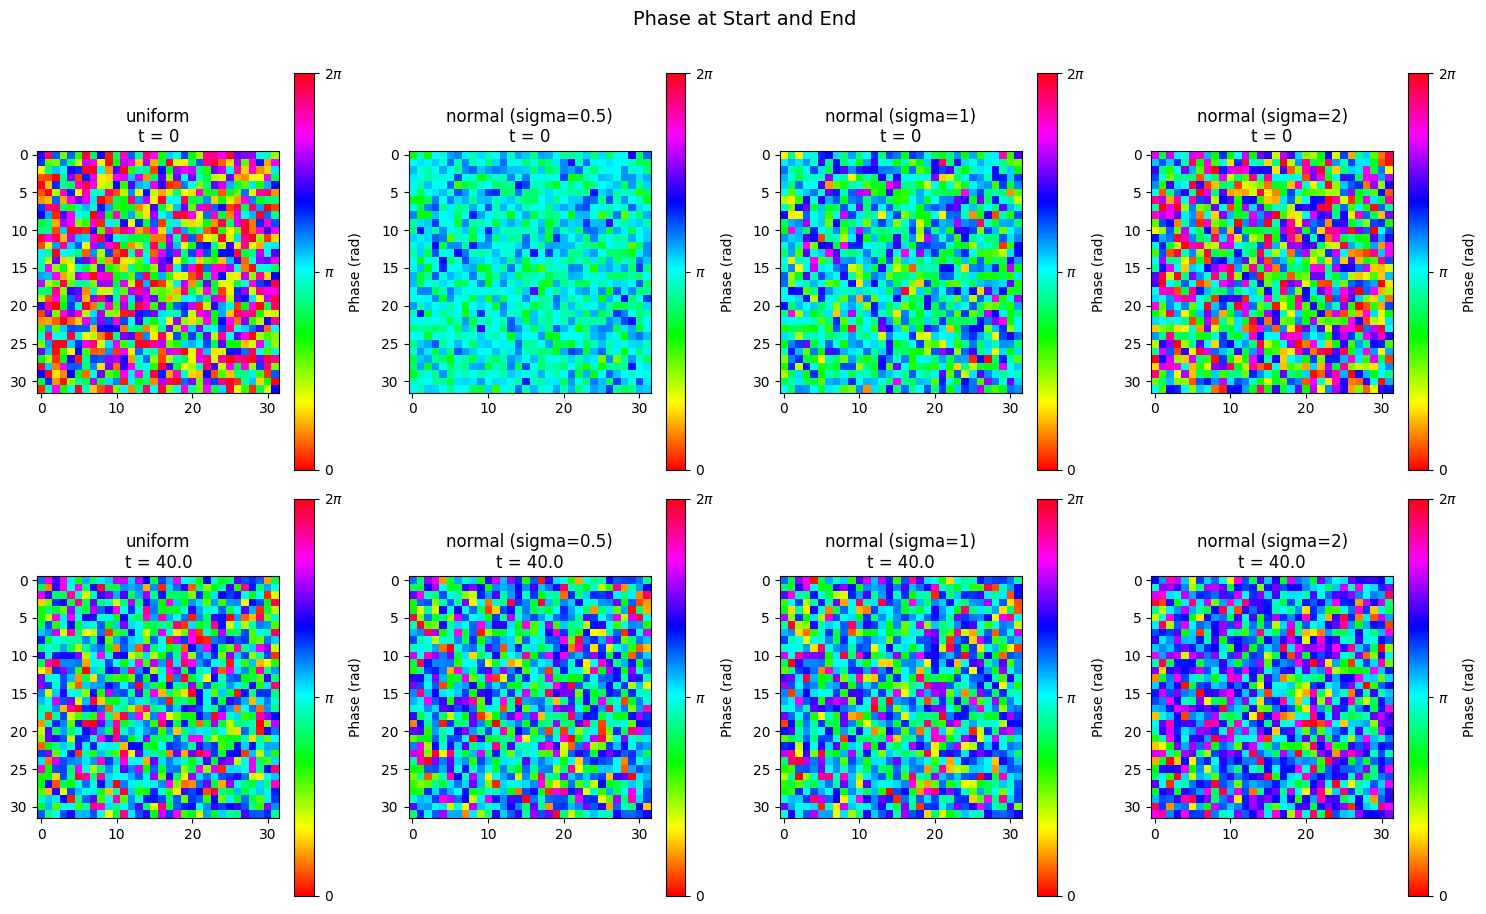

In [14]:
fig, axes = plt.subplots(2, len(init_modes), figsize=(15, 9))
for col, (label, res) in enumerate(results_init.items()):
    grid = res["grid"]
    plot_2d(grid.unflatten(res["state_list"][0]["theta"]), variable="phase",
            ax=axes[0, col], title=f"{label}\nt = 0")
    plot_2d(grid.unflatten(res["state_list"][-1]["theta"]), variable="phase",
            ax=axes[1, col], title=f"{label}\nt = {T_END}")
plt.suptitle("Phase at Start and End", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 3) Natural frequency distributions

In [17]:
## 3) Natural frequency distributions
init_modes = {
    "uniform": InitOmegaConfig(mode="uniform"),
    "normal (sigma=0.5)": InitOmegaConfig(mode="normal", mu=np.pi, sigma=0.5),
    "normal (sigma=1)": InitOmegaConfig(mode="normal", mu=np.pi, sigma=1),
    "normal (sigma=2)": InitOmegaConfig(mode="normal", mu=np.pi, sigma=2)
}

results_init = {}

# Base sim config
coupling_cfg = CouplingConfig(mode="uniform", base_strength=0.8) # Picking transitional K
init_theta = InitThetaConfig(mode="normal", mu=np.pi, sigma=1)

for label, init_cfg in init_modes.items():
    # Configure sims
    cfg = SimulationConfig(
        grid=grid_cfg,
        coupling=coupling_cfg,
        initial_theta=init_theta,
        initial_omega=init_cfg,
        seed=SEED,
    )

    sim = build_simulation(config=cfg, rng=RNG)

    results = sim.run((0, T_END), dt, rng=RNG)
    t_list = results['ts'].tolist()
    state_list = [{'theta': th, 'theta_dot': dth, 'omega': results['omega']} for th, dth in zip(results['theta'], results['theta_dot'])]
    
    t_R = t_list
    R_vals, _ = get_R(results['theta'])
    
    results_init[label] = {
        "t_list": t_list, "state_list": state_list,
        "t_R": t_R, "R": R_vals,
        "theta0": state_list[0]["theta"],
        "grid": sim.grid,
    }
    
    print(f"{label}: R_final = {R_vals[-1]:.3f}")

uniform: R_final = 0.006
normal (sigma=0.5): R_final = 0.462
normal (sigma=1): R_final = 0.024
normal (sigma=2): R_final = 0.041


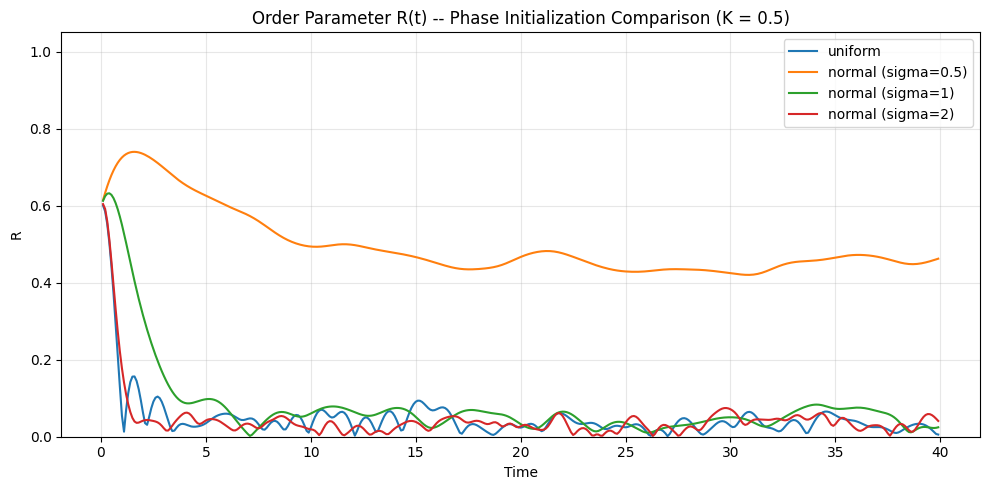

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
for label, res in results_init.items():
    ax.plot(res["t_R"], res["R"], linewidth=1.5, label=label)
ax.set_xlabel("Time")
ax.set_ylabel("R")
ax.set_ylim(0, 1.05)
ax.set_title("Order Parameter R(t) -- Natural Frequency Initialization Comparison (K = 0.8)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

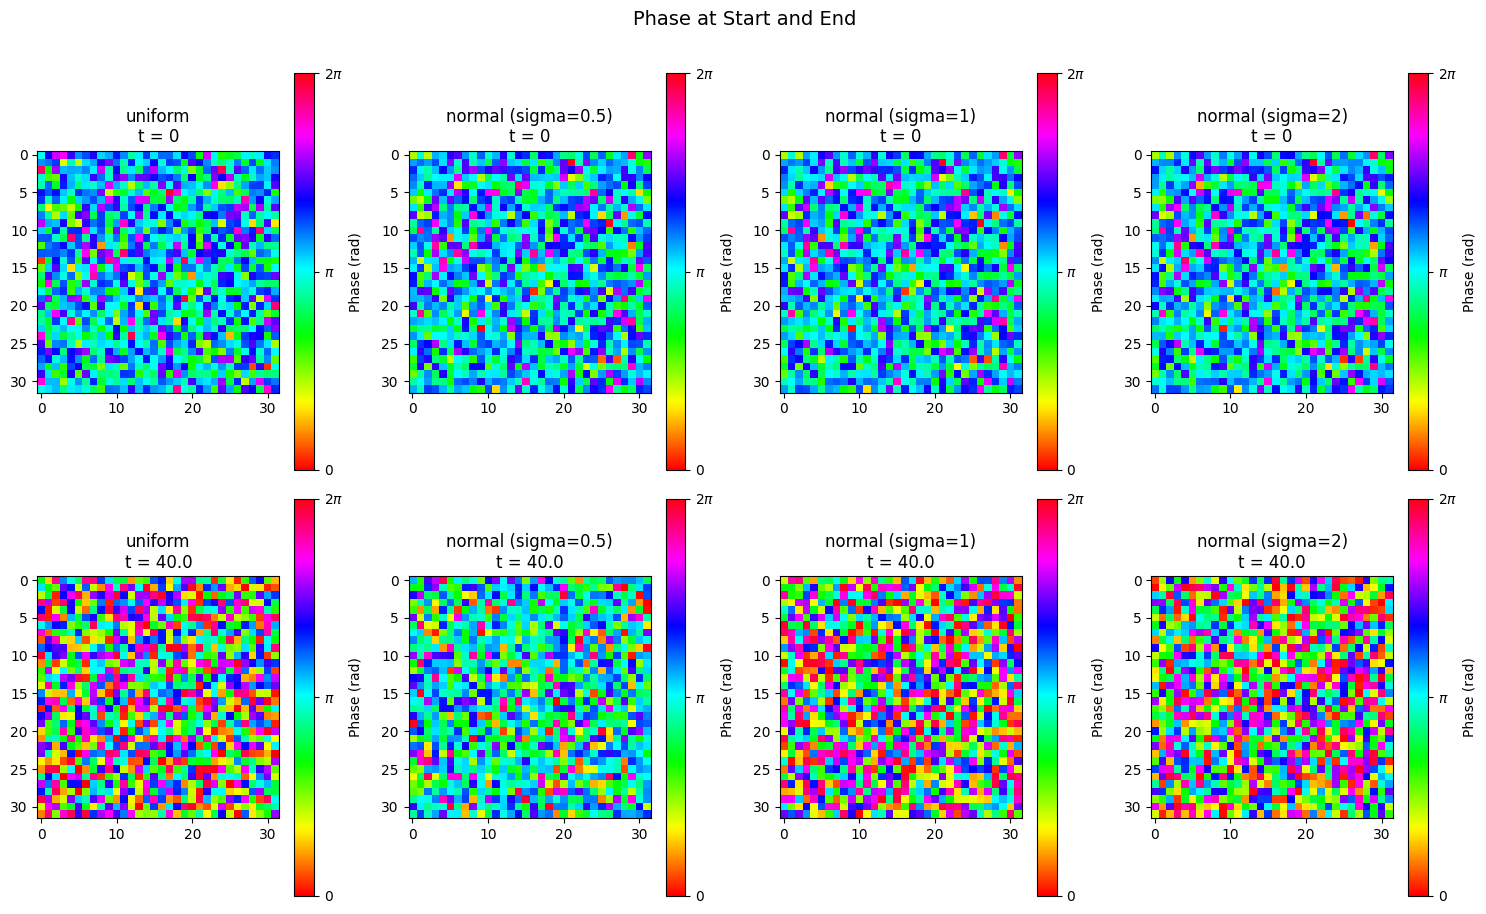

In [19]:
fig, axes = plt.subplots(2, len(init_modes), figsize=(15, 9))
for col, (label, res) in enumerate(results_init.items()):
    grid = res["grid"]
    plot_2d(grid.unflatten(res["state_list"][0]["theta"]), variable="phase",
            ax=axes[0, col], title=f"{label}\nt = 0")
    plot_2d(grid.unflatten(res["state_list"][-1]["theta"]), variable="phase",
            ax=axes[1, col], title=f"{label}\nt = {T_END}")
plt.suptitle("Phase at Start and End", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()